# **Customer Churn(AI) -- Capstone Project**

In [1]:
# Import important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/content/customer_churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## **A) Data Manipulation**
* a. Find the total number of male customers
* b. Find the total number of customers whose Internet Service is ‘DSL’
* c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’
* d. Extract all those customers whose tenure is less than 10 months or their Total charges is less than 500$ & store the result in ‘new_customer’

In [5]:
sum(data['gender']=='Male')

3555

In [6]:
sum(data['InternetService']=='DSL')

2421

In [7]:
new_customer = data[(data['gender']=='Female') & (data['SeniorCitizen']==1) & (data['PaymentMethod']=='Mailed check')]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No


In [8]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

new_customer = data[(data['tenure']<10)|(data['TotalCharges']<500)]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


## **B) Data Visualization:**
* a. Build a pie-chart to show the distribution of customers would be churning out
* b. Build a bar-plot to show the distribution of ‘Internet Service’

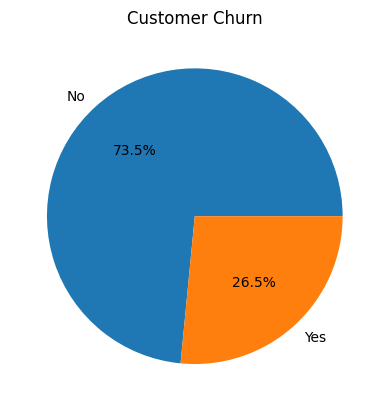

In [9]:
plt.pie(data['Churn'].value_counts(), labels=data['Churn'].value_counts().index, autopct='%1.1f%%')
plt.title("Customer Churn")
plt.show()

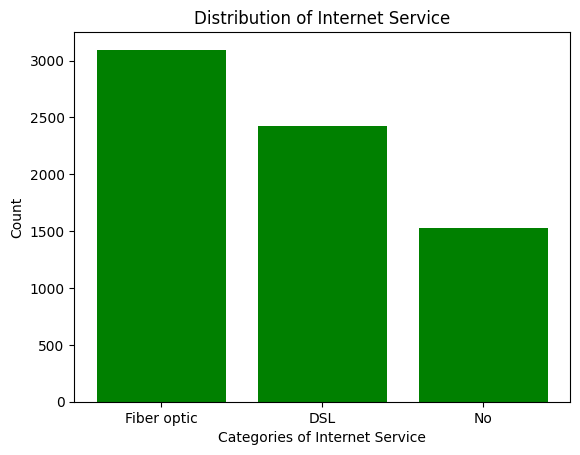

In [10]:
plt.bar(data['InternetService'].value_counts().index, data['InternetService'].value_counts(), color='green')
plt.title("Distribution of Internet Service")
plt.xlabel("Categories of Internet Service")
plt.ylabel("Count")
plt.show()

## **C) Model Building:**
* a. Build a sequential model using Keras, to find out if the customerwouldchurn or not, using ‘tenure’ as the feature and ‘Churn’ as the dependent/target column:
  * i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.
  * ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation
  * iii. function Use ‘Adam’ as the optimization algorithm
  * iv. Fit the model on the train set, with number of epochs to be 150
  * v. Predict the values on the test set and build a confusion matrix
  * vi. Plot the ‘Accuracy vs Epochs’ graph



In [11]:
x = data[['tenure']]
y = data['Churn'].map({'Yes':1, 'No':0})

In [12]:
x

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


In [13]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [15]:
x_train, y_train

(      tenure
 1695      54
 1095       1
 3889      13
 3667      24
 2902       6
 ...      ...
 3772       1
 5191      23
 5226      12
 5390      12
 860       26
 
 [4930 rows x 1 columns],
 1695    0
 1095    0
 3889    0
 3667    0
 2902    0
        ..
 3772    1
 5191    0
 5226    0
 5390    1
 860     0
 Name: Churn, Length: 4930, dtype: int64)

In [16]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(12, input_dim=1, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(x_train, y_train, epochs=150, verbose=1, validation_data=(x_test, y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3775 - loss: 1.5857 - val_accuracy: 0.7283 - val_loss: 0.6699
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7435 - loss: 0.6631 - val_accuracy: 0.7283 - val_loss: 0.6508
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7342 - loss: 0.6449 - val_accuracy: 0.7283 - val_loss: 0.6338
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7259 - loss: 0.6310 - val_accuracy: 0.7283 - val_loss: 0.6202
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7338 - loss: 0.6150 - val_accuracy: 0.7283 - val_loss: 0.6097
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7301 - loss: 0.6067 - val_accuracy: 0.7283 - val_loss: 0.6018
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - loss: 0.5909 - val_accuracy: 0.7283 - val_loss: 0.5961
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7377 - loss: 0.5888 - val_acc

In [18]:
np.mean(history.history['accuracy'])

0.7360987095038096

In [19]:
np.mean(history.history['val_accuracy'])

0.7283483147621155

In [20]:
score = model.evaluate(x_test, y_test, verbose=1)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7267 - loss: 0.5868
Test loss: 0.5851097702980042
Test accuracy: 0.7283483147621155


In [21]:
y_pred = model.predict(x_test)
y_pred

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.26249436],
       [0.26249436],
       [0.26249436],
       ...,
       [0.26249436],
       [0.26249436],
       [0.26249436]], dtype=float32)

In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred.round())
cm

array([[1539,    0],
       [ 574,    0]])

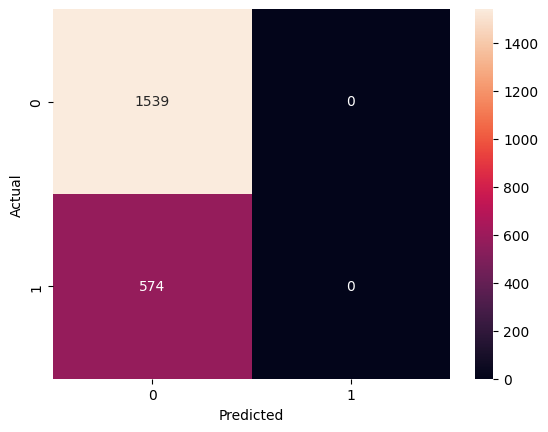

In [23]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

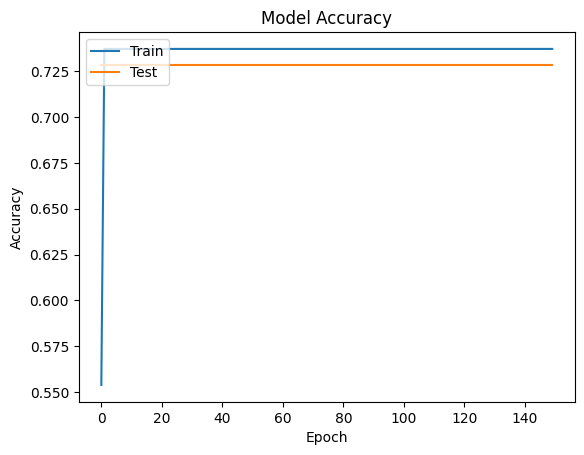

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

* b. Build the 2nd model using same target and feature variables:
  * i. Add a drop-out layer after the input layer with drop-out value of 0.3
  * ii. Add a drop-out layer after the hidden layer with drop-out value of 0.2
  * iii. Predict the values on the test set and build a confusion matrix
  * iv.  Plot the ‘Accuracy vs Epochs’ graph


In [25]:
from keras.layers import Dropout

model2 = Sequential()
model2.add(Dense(12, input_dim=1, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(8, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
history2 = model2.fit(x_train, y_train, epochs=150, verbose=1, validation_data=(x_test, y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5552 - loss: 1.6612 - val_accuracy: 0.7283 - val_loss: 0.5415
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6754 - loss: 0.7407 - val_accuracy: 0.7283 - val_loss: 0.5116
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 0.6580 - val_accuracy: 0.7283 - val_loss: 0.5241
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7175 - loss: 0.5943 - val_accuracy: 0.7283 - val_loss: 0.5306
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7222 - loss: 0.5698 - val_accuracy: 0.7283 - val_loss: 0.5370
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7332 - loss: 0.5516 - val_accuracy: 0.7283 - val_loss: 0.5374
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7450 - loss: 0.5356 - val_accuracy: 0.7283 - val_loss: 0.5219
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7465 - loss: 0.5216 - val_acc

In [27]:
score = model2.evaluate(x_test, y_test, verbose=1)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7267 - loss: 0.5163
Test loss: 0.5203296542167664
Test accuracy: 0.7283483147621155


In [28]:
y_pred2 = model2.predict(x_test)
y_pred2

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.44621134],
       [0.23151344],
       [0.18550342],
       ...,
       [0.15670873],
       [0.3394401 ],
       [0.32813177]], dtype=float32)

In [29]:
cm = confusion_matrix(y_test, y_pred2.round())
cm

array([[1539,    0],
       [ 574,    0]])

Text(50.722222222222214, 0.5, 'Actual')

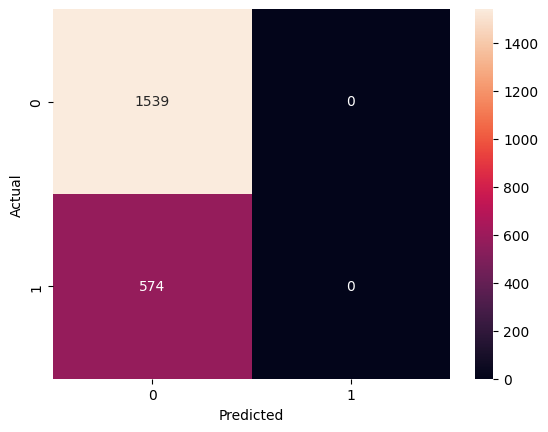

In [30]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

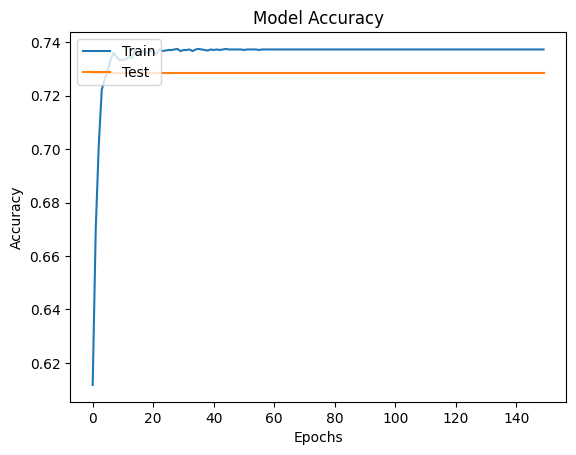

In [31]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

* c. Build the 3rd model using ‘Tenure’, ’Monthly Charges’ & ‘Total Charges’ as the features and ‘Churn’ as the dependent/target column:
  * i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.
  * ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function
  * iii. Use ‘Adam’ as the optimization algorithm
  * iv. Fit the model on the train set, with number of epochs to be 150
  * v. Predict the values on the test set and build a confusion matrix
  * vi. Plot the ‘Accuracy vs Epochs’ graph

In [32]:
x = data[['tenure','MonthlyCharges', 'TotalCharges']]
x = x.fillna(0)
x

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [33]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


In [34]:
y = data['Churn'].map({'Yes':1, 'No':0})
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [36]:
model3 = Sequential()
model3.add(Dense(12, input_dim=3, activation='relu'))
model3.add(Dense(8, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model3.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 12)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
history3 = model3.fit(x_train, y_train, epochs=150, verbose=1, validation_data=(x_test, y_test))

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4389 - loss: 100.8691 - val_accuracy: 0.5840 - val_loss: 1.0430
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5927 - loss: 0.9680 - val_accuracy: 0.7317 - val_loss: 0.9148
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7129 - loss: 0.7316 - val_accuracy: 0.7416 - val_loss: 0.6173
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7213 - loss: 0.6440 - val_accuracy: 0.7586 - val_loss: 0.7357
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7344 - loss: 0.7383 - val_accuracy: 0.7695 - val_loss: 0.9259
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7354 - loss: 0.6720 - val_accuracy: 0.7785 - val_loss: 0.7918
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7399 - loss: 1.1357 - val_accuracy: 0.7733 - val_loss: 1.1318
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7340 - loss: 1.3432 - val_a

In [39]:
score = model3.evaluate(x_test, y_test, verbose=1)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7789 - loss: 0.5618
Test loss: 0.5768427848815918
Test accuracy: 0.7823000550270081


In [40]:
y_pred3 = model3.predict(x_test)
y_pred3

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.37544504],
       [0.020326  ],
       [0.00933534],
       ...,
       [0.00393175],
       [0.24409944],
       [0.1008012 ]], dtype=float32)

In [41]:
cm = confusion_matrix(y_test, y_pred3.round())
cm

array([[1463,   76],
       [ 384,  190]])

Text(50.722222222222214, 0.5, 'Actual')

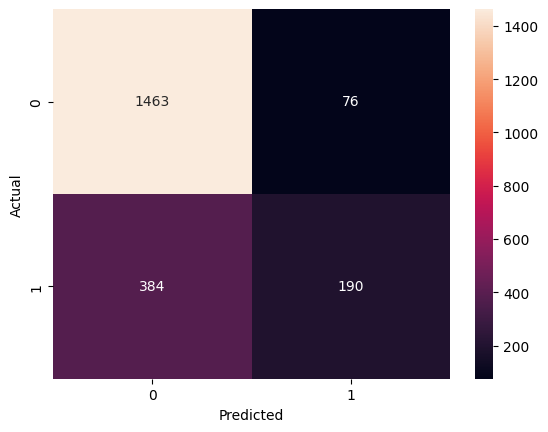

In [42]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

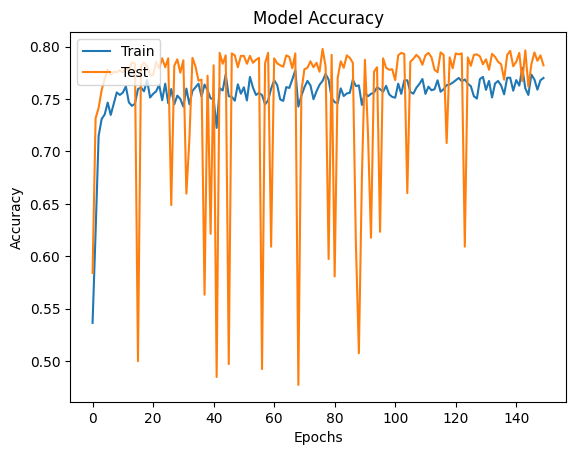

In [43]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Test'], loc='upper left')
plt.show()

**Conclusion**
* **With first model we have got validation accuracy of 72.83%**
* **In second model with adding dropout layer we have got same validation accuracy with underfitting**
* **In third model by using more features we have got accuracy of 78.23%.**

